In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback

In [2]:
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

In [3]:
llm_model = "gpt-4o-2024-08-06"

agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools="all",
    streaming=False,
    verbose=True,
    modifysim_no_run=False,
    use_memory=True,
)

In [4]:
prompt_partA = "Simulate the protein 2F4K at 350 K for 1 ps. Compute the radius of gyration."

with get_openai_callback() as cb:
    print(agent.run(prompt_partA, callbacks=[cb]))
    print(cb)
    print('LLM cost:',calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name))



> Entering new AgentExecutor chain...
Thought: To simulate the protein 2F4K at 350 K for 1 ps and compute the radius of gyration, I need to first download the PDB file for 2F4K, set up and run the simulation, and then calculate the radius of gyration from the resulting trajectory. I will start by downloading the PDB file for 2F4K.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "2F4K"
}
```PDB file found with this ID: 2F4K

Observation: Succeeded. Downloaded the PDB file:2F4K_163329
Thought:To proceed with the simulation of the protein 2F4K at 350 K for 1 ps, I need to set up and run the simulation using the downloaded PDB file. After the simulation, I will compute the radius of gyration. Let's set up and run the simulation first.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "2F4K_163329",
    "forcefield_files": ["amber99sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
  

<Figure size 640x480 with 0 Axes>

In [5]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 2F4K_163329: PDB file downloaded from RSCB
 PDBFile ID: 2F4K_163329
 2F4K_163337: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_163339: Initial positions for simulation sim0_163339
 sim0_163339: Basic Simulation of Protein 2F4K_163337
 rec0_163340: Simulation trajectory for protein 2F4K_163337 and simulation sim0_163339
 rec1_163340: Simulation state log for protein 2F4K_163337 and simulation sim0_163339
 rec2_163340: Simulation pdb frames for protein 2F4K_163337 and simulation sim0_163339
 rgy_rec0_163340: Radii of gyration per frame for rec0_163340
 fig0_163344: Plot of radii of gyration over time for rec0_163340


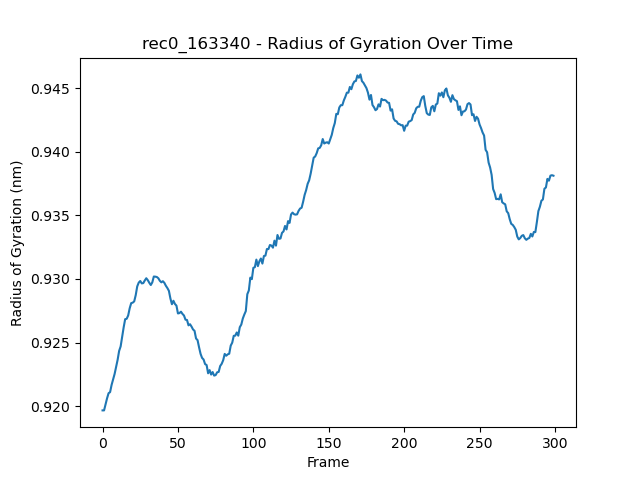

In [6]:
# check rgy plot
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_163344'))

In [7]:
prompt_partB = """Earlier, we did a basic simulation on 2F4K at 350 K. First, estimate
the box size we may need to accomodate the unfolding of 2F4K. Use that information to 
modify the simulation script to solvate and add a specific amount of padding."""

with get_openai_callback() as cb:
    print(agent.run(prompt_partB, callbacks=[cb]))
    print(cb)
    print('LLM cost:',calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name))



> Entering new AgentExecutor chain...
Thought: To estimate the box size needed to accommodate the unfolding of 2F4K, I will first need to download the PDB file for 2F4K and then calculate its radius of gyration. This will give an idea of the protein's size in its folded state. I will then add a specific padding to account for unfolding. After estimating the box size, I will modify the simulation script to include solvation and the specified padding.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": "2F4K"
}
```PDB file found with this ID: 2F4K

Observation: Succeeded. Downloaded the PDB file:2F4K_163915
Thought:Action:
```json
{
  "action": "RadiusofGyrationTool",
  "action_input": {
    "traj_file": "2F4K_163915",
    "top_file": "2F4K_163915"
  }
}
```plot_name:  FIG_rgy_2F4K_163915_20251230_163916.png
plot_path /Users/quinny/repos/MDCrow/ckpt/ckpt_0/figures/FIG_rgy_2F4K_163915_20251230_163916.png

Observation: Succeeded. Radii of gyration saved to /Users/quinny

<Figure size 640x480 with 0 Axes>

In [20]:
prompt_partC = "Earlier, we did modify the simulation script for the box size. \
    Now, modify the script again so it can run for 1 ns."

with get_openai_callback() as cb:
    print(agent.run(prompt_partC, callbacks=[cb]))
    print(cb)
    print('LLM cost:',calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name))



> Entering new AgentExecutor chain...
Question: How do I modify the simulation script to run for 1 nanosecond (ns) with a timestep of 2 femtoseconds (fs)?
Thought: To achieve a simulation duration of 1 ns with a timestep of 2 fs, I need to set the number of steps to 500,000. I will use the ModifyScriptTool to implement this change.
Action:
```json
{
  "action": "ModifyScriptTool",
  "action_input": {
    "script_id": "previous_script_id",
    "query": "Set the simulation to run for 500,000 steps with a timestep of 2 fs."
  }
}
```
Observation: Failed. File ID not found: previous_script_id, make sure the script ID is correct
Thought:```json
{
  "action": "ListRegistryPaths",
  "action_input": {
    "paths": "paths"
  }
}
```
Observation: Succeeded. Files found in registry: 2F4K_163329: PDB file downloaded from RSCB, PDBFile ID: 2F4K_163329, 2F4K_163337: Cleaned File:  Removed Heterogens, and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added 

## analyze the simulation outputs

In [21]:
# reorganize output files
import os
import shutil

dest_dir = agent.ckpt_dir + "/user_files"
suffix = "1ns"
os.makedirs(dest_dir, exist_ok=True)

files = ['trajectory.dcd', 'trajectory.pdb', 'log.txt', 'checkpoint.chk', 'simulation_initial_positions.pdb']

for f in files:
    if os.path.exists(f):
        name, ext = os.path.splitext(f)
        new_name = f"{name}_{suffix}{ext}"
        shutil.move(f, os.path.join(dest_dir, new_name))
        print(f"✓ {f} → {new_name}")

uploaded_files = [
    (os.path.join(dest_dir, f'log_{suffix}.txt'), "Log file of the records for Temperature, Energy, Volume, Density of the simulation"),
    (os.path.join(dest_dir, f'trajectory_{suffix}.pdb'), "PDB trajectory records in pdb format"),
    (os.path.join(dest_dir, f'trajectory_{suffix}.dcd'), "Trajectory of the simulation in dcd format"),
    (os.path.join(dest_dir, f'simulation_initial_positions_{suffix}.pdb'), "Initial positions of the simulation in pdb format")
]

✓ trajectory.dcd → trajectory_1ns.dcd
✓ trajectory.pdb → trajectory_1ns.pdb
✓ log.txt → log_1ns.txt
✓ checkpoint.chk → checkpoint_1ns.chk
✓ simulation_initial_positions.pdb → simulation_initial_positions_1ns.pdb


## fix this later -- analyze the uploaded files. have to give it one by one to separate time stamps

In [ ]:
# reorganize output files
import os
import shutil

dest_dir = agent.ckpt_dir + "/user_files"
os.makedirs(dest_dir, exist_ok=True)

files = ['trajectory.dcd', 'trajectory.pdb', 'log.txt', 'checkpoint.chk', 'simulation_initial_positions.pdb']

for f in files:
    if os.path.exists(f):
        name, ext = os.path.splitext(f)
        new_name = f"{name}_1ps{ext}"
        shutil.move(f, os.path.join(dest_dir, new_name))
        print(f"✓ {f} → {new_name}")

✓ trajectory.dcd → trajectory_1ps.dcd
✓ trajectory.pdb → trajectory_1ps.pdb
✓ log.txt → log_1ps.txt
✓ checkpoint.chk → checkpoint_1ps.chk
✓ simulation_initial_positions.pdb → simulation_initial_positions_1ps.pdb


In [18]:
# Create uploaded_files with detailed descriptions
uploaded_files = [
    (os.path.join(dest_dir, 'log_1ps.txt'), "Log file of the records for Temperature, Energy, Volume, Density of the simulation"),
    (os.path.join(dest_dir, 'trajectory_1ps.pdb'), "PDB trajectory records in pdb format"),
    (os.path.join(dest_dir, 'trajectory_1ps.dcd'), "Trajectory of the simulation in dcd format"),
    (os.path.join(dest_dir, 'simulation_initial_positions_1ps.pdb'), "Initial positions of the simulation in pdb format")
]

In [19]:
uploaded_files


[('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/log_1ps.txt',
  'Log file of the records for Temperature, Energy, Volume, Density of the simulation'),
 ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.pdb',
  'PDB trajectory records in pdb format'),
 ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.dcd',
  'Trajectory of the simulation in dcd format'),
 ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/simulation_initial_positions_1ps.pdb',
  'Initial positions of the simulation in pdb format')]

In [13]:
agent_with_new_files = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools="all",
    streaming=False,
    verbose=True,
    modifysim_no_run=False,
    use_memory=True,
    ckpt_dir=agent.ckpt_dir,
    uploaded_files=uploaded_files
)

Adding file ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.dcd', 'Simulation output: trajectory_1ps.dcd')

<class 'tuple'>
Adding file /Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.dcd with ID UPL_020251230_170125

Adding file ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.pdb', 'Simulation output: trajectory_1ps.pdb')

<class 'tuple'>
Adding file /Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/trajectory_1ps.pdb with ID UPL_120251230_170125

Adding file ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/log_1ps.txt', 'Simulation output: log_1ps.txt')

<class 'tuple'>
Adding file /Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/log_1ps.txt with ID UPL_220251230_170125

Adding file ('/Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/simulation_initial_positions_1ps.pdb', 'Simulation output: simulation_initial_positions_1ps.pdb')

<class 'tuple'>
Adding file /Users/quinny/repos/MDCrow/ckpt/ckpt_0/user_files/simulation_initial

In [15]:
prompt_partB_analysis="I just uploaded the files from the simulation you ran for me. \
    Please analyze the results and compute RMSD, SASA, and radius of gyration."

with get_openai_callback() as cb:
    print(agent_with_new_files.run(prompt_partB_analysis, callbacks=[cb]))
    print(cb)
    print('LLM cost:',calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent_with_new_files.llm.model_name))



> Entering new AgentExecutor chain...
Thought: To analyze the simulation results, I need to compute the RMSD, SASA, and radius of gyration using the uploaded files. First, I will list the available files to identify the trajectory and topology files needed for the analysis.

Action:
```
{
  "action": "ListRegistryPaths",
  "action_input": {
    "paths": "paths"
  }
}
```
Observation: Succeeded. Files found in registry: 2F4K_163329: PDB file downloaded from RSCB, PDBFile ID: 2F4K_163329, 2F4K_163337: Cleaned File:  Removed Heterogens, and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. , top_sim0_163339: Initial positions for simulation sim0_163339, sim0_163339: Basic Simulation of Protein 2F4K_163337, rec0_163340: Simulation trajectory for protein 2F4K_163337 and simulation sim0_163339, rec1_163340: Simulation state log for protein 2F4K_163337 and simulation sim0_163339, rec2_163340: Simulation pdb frame

In [ ]:
# # merged code for next time: 
# import os
# import shutil

# dest_dir = agent.ckpt_dir + "/user_files"
# os.makedirs(dest_dir, exist_ok=True)

# files = ['trajectory.dcd', 'trajectory.pdb', 'log.txt', 'checkpoint.chk', 'simulation_initial_positions.pdb']

# for f in files:
#     if os.path.exists(f):
#         name, ext = os.path.splitext(f)
#         new_name = f"{name}_1ps{ext}"
#         shutil.move(f, os.path.join(dest_dir, new_name))
#         print(f"✓ {f} → {new_name}")

# # Create uploaded_files with detailed descriptions
# uploaded_files = [
#     (os.path.join(dest_dir, 'log_1ps.txt'), "Log file of the records for Temperature, Energy, Volume, Density of the simulation"),
#     (os.path.join(dest_dir, 'trajectory_1ps.pdb'), "PDB trajectory records in pdb format"),
#     (os.path.join(dest_dir, 'trajectory_1ps.dcd'), "Trajectory of the simulation in dcd format"),
#     (os.path.join(dest_dir, 'simulation_initial_positions_1ps.pdb'), "Initial positions of the simulation in pdb format")
# ]